# Fleet-level time-explicit LCA of electric vehicles — explicit process/product

This notebook is a streamlined re-implementation of [the fleet EV example](./example_electric_vehicle_fleet.ipynb)
using the **explicit process/product paradigm** that `bw_timex` inherits from Brightway 2.5+.

## What "explicit process/product" means

In the classic Brightway model, an *activity* bundles two things: **a process** (the production
operation) and **its reference product** (the unit it outputs). They share one node and one
matrix column. That is convenient, but it conflates *who is doing the work* with *what is being
demanded*.

The explicit paradigm separates them:

- A **product node** (`type=bd.labels.product_node_default`) is a *thing* — a kg of methanol, a
  vehicle-lifetime, a kWh. It carries no exchanges and has no `reference product` field of its
  own; it just sits in the system as a row of the technosphere matrix that you can *demand*.
- A **process node** (`type=bd.labels.process_node_default`) is an *operation*. All its
  technosphere/biosphere/production edges live here. Its only "output" is one (or more)
  production edges pointing at product nodes.

With the two split, every product node has a clean **upstream side** (the process(es)
producing it) and **downstream side** (the consumers demanding it). That separation is what
lets us put **temporal distributions on both sides** of the same product (see the next
section), which is the conceptual hook the rest of this notebook hangs on.

## What this notebook does

1. We use [**flodym**](https://github.com/pik-piam/flodym) to run a stock-driven dynamic
   Material Flow Analysis (dMFA) of an EV fleet. flodym gives us, from an exogenous stock
   trajectory and a Weibull lifetime distribution, three things: the annual inflow (production),
   the stock-by-cohort matrix (who is on the road in which year), and the age-resolved
   survival/retirement profiles. These become the relative `TemporalDistribution`s we feed to
   `bw_timex`.
2. We model the fleet with **a single foreground process + a single product**: no aggregator
   wrapper, no per-vehicle build/EOL sub-processes. The cohort timing rides on the *production*
   edge `ev_fleet_process → ev_fleet_product`; the age-relative TDs ride on the technosphere
   edges of `ev_fleet_process`. `temporal_evolution_factors` with `reference="consumer"` on the
   electricity edge then track **vintage-locked efficiencies**: a vehicle built in 2020 keeps
   its 2020 kWh/km even when it is still driving in 2030 alongside more efficient cohorts.

What this gives us: in any calendar year (e.g. 2030) `bw_timex` evaluates the fleet's
electricity demand cohort-by-cohort — older vehicles consuming more, newer vehicles consuming
less — at the same time as the background system itself decarbonises.

> **Note:** Fully reproducible — only requires `bw_timex`, `flodym`, `numpy`, `pandas`,
> `matplotlib`, `scipy`. We use tiny made-up background databases for 2020/2030/2040 instead
> of ecoinvent or premise.


## Project and background databases


In [1]:
import bw2data as bd

bd.projects.set_current("electric_vehicle_fleet_explicit")
for db in list(bd.databases):
    del bd.databases[db]


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.11/site-packages/bw2calc/__init__.py:54: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


We register a one-flow biosphere and three time-stamped background databases (2020, 2030, 2040).
Every background process emits CO2 only, and the per-unit emissions decrease over time, representing
a decarbonising background system.


In [2]:
biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write({("biosphere", "CO2"): {"type": "emission", "name": "carbon dioxide"}})

background_2020 = bd.Database("background_2020"); background_2020.register(); background_2020.write({})
background_2030 = bd.Database("background_2030"); background_2030.register(); background_2030.write({})
background_2040 = bd.Database("background_2040"); background_2040.register(); background_2040.write({})

background_databases = [background_2020, background_2030, background_2040]

process_co2_emissions = {
    "glider":         (10,   5,    2.5),    # kg CO2 / kg in 2020, 2030, 2040
    "powertrain":     (20,   10,   7.5),
    "battery":        (10,   5,    4),
    "electricity":    (0.5,  0.25, 0.075),  # kg CO2 / kWh
    "glider_eol":     (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol":    (1,    0.5,  0.25),
}

node_co2 = biosphere.get("CO2")
for component_name, gwis in process_co2_emissions.items():
    for database, gwi in zip(background_databases, gwis):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=gwi, type="biosphere").save()


100%|██████████| 1/1 [00:00<00:00, 1540.89it/s]

08:52:18+0200 [info     ] Vacuuming database            


## Per-vehicle assumptions

We keep the same simple bill-of-materials and use-phase parameters as in the standalone notebook.
These are applied *per vehicle*; the flodym stock model below scales them to the fleet.


In [3]:
ELECTRICITY_CONSUMPTION = 0.2      # kWh/km (vintage-2020 baseline)
ANNUAL_MILEAGE          = 12_000   # km/year per vehicle in stock

MASS_GLIDER     = 840   # kg
MASS_POWERTRAIN = 80    # kg
MASS_BATTERY    = 280   # kg


## Dynamic stock model with flodym

We solve a stock-driven dMFA on an annual grid from 2015 to 2055:

- An exogenously prescribed S-curve stock trajectory.
- A Weibull lifetime (shape `k = 5`, scale `λ = 14` years, mean ~13 years).

From this, flodym returns annual inflow, outflow and the *stock-by-cohort* matrix — i.e. how many
vehicles of every cohort are still on the road in every year.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

from flodym import (
    Dimension,
    DimensionSet,
    StockArray,
    StockDrivenDSM,
    WeibullLifetime,
)


In [5]:
YEAR_START = 2015
YEAR_END   = 2055
years = np.arange(YEAR_START, YEAR_END + 1)

time_dim = Dimension(name="Time", letter="t", items=years.tolist(), dtype=int)
dims = DimensionSet(dim_list=[time_dim])

STOCK_SATURATION = 2_000_000
STOCK_MIDPOINT   = 2030
STOCK_STEEPNESS  = 0.35
stock_values = STOCK_SATURATION / (1 + np.exp(-STOCK_STEEPNESS * (years - STOCK_MIDPOINT)))
stock = StockArray(dims=dims, name="ev_fleet", values=stock_values)

WEIBULL_SHAPE = 5.0
WEIBULL_SCALE = 14.0
lifetime_model = WeibullLifetime(dims=dims)
lifetime_model.set_prms(
    weibull_shape=np.full(dims.shape, WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, WEIBULL_SCALE),
)

dsm = StockDrivenDSM(dims=dims, stock=stock, lifetime_model=lifetime_model)
dsm.compute()

inflow_values  = dsm.inflow.values
outflow_values = dsm.outflow.values
stock_by_cohort = dsm.get_stock_by_cohort()  # shape (year, cohort), strictly upper triangular


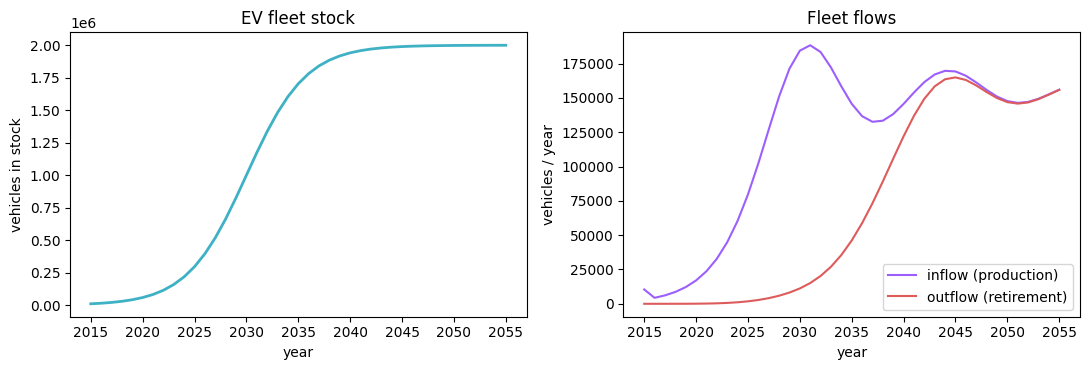

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(years, dsm.stock.values, color="#3fb1c5", lw=2)
axes[0].set(xlabel="year", ylabel="vehicles in stock", title="EV fleet stock")
axes[1].plot(years, inflow_values,  label="inflow (production)",  color="#9c5ffd")
axes[1].plot(years, outflow_values, label="outflow (retirement)", color="#dd5b5b")
axes[1].set(xlabel="year", ylabel="vehicles / year", title="Fleet flows")
axes[1].legend()
fig.tight_layout()


### Stock-by-cohort: who is on the road in 2030?

The stock-by-cohort matrix is the key object motivating this notebook. Picking a single calendar
year (e.g. 2030) and stacking the column tells us how the fleet on the road that year decomposes
into vehicles produced in earlier cohorts. That decomposition is what `bw_timex` will replicate
from our two TDs (cohort × age) — and what makes per-cohort `temporal_evolution_factors`
meaningful.


In 2030: 1,000,000 vehicles in service, oldest cohort still on the road: 2015.


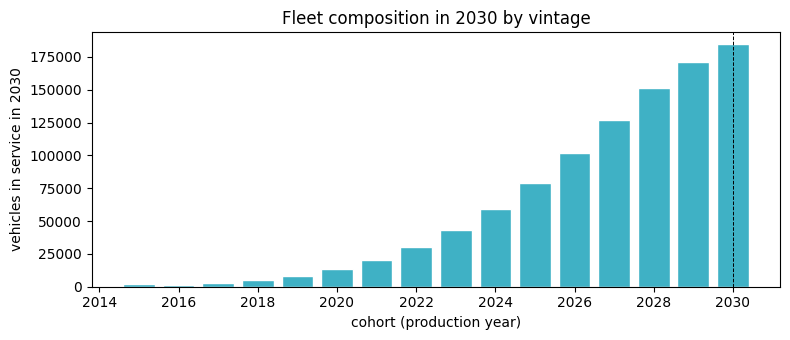

In [7]:
TARGET_YEAR = 2030
yr_idx = int(np.where(years == TARGET_YEAR)[0][0])
stock_in_target_year = stock_by_cohort[yr_idx, : yr_idx + 1]
cohort_years_in_target = years[: yr_idx + 1]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(cohort_years_in_target, stock_in_target_year, color="#3fb1c5", edgecolor="white")
ax.set(xlabel="cohort (production year)",
       ylabel=f"vehicles in service in {TARGET_YEAR}",
       title=f"Fleet composition in {TARGET_YEAR} by vintage")
ax.axvline(TARGET_YEAR, color="k", ls="--", lw=0.7)
fig.tight_layout()

print(f"In {TARGET_YEAR}: {stock_in_target_year.sum():,.0f} vehicles in service, "
      f"oldest cohort still on the road: {cohort_years_in_target[stock_in_target_year > 1][0]}.")


### Restrict the cohort window

We scope the LCA to vehicles whose production falls in `[ANALYSIS_START, ANALYSIS_END]`. This
keeps the build phase entirely within the horizon of our background databases. The use phase and
end-of-life of these cohorts may extend past `ANALYSIS_END`, which is exactly what `bw_timex` is
designed to handle.


In [8]:
ANALYSIS_START = 2020
ANALYSIS_END   = 2050
FU_YEAR        = 2035   # anchoring year for the TimexLCA timeline

mask = (years >= ANALYSIS_START) & (years <= ANALYSIS_END)
years_window  = years[mask]
inflow_window = inflow_values[mask]
n_total_inflow = float(inflow_window.sum())

print(f"Cohort window: {ANALYSIS_START}-{ANALYSIS_END}")
print(f"Total vehicles produced in window: {n_total_inflow:>12,.0f}")


Cohort window: 2020-2050
Total vehicles produced in window:    4,132,670


## From flodym to `TemporalDistribution`s

Three flodym outputs become three relative TDs that we hang on the foreground edges:

```{mermaid}
flowchart LR
    stock[stock trajectory<br/>S-curve]:::in --> dsm
    lt[Weibull lifetime<br/>shape k, scale &lambda;]:::in --> dsm
    dsm{{flodym StockDrivenDSM}}:::dsm
    dsm --> inflow[annual inflow<br/>vehicles / year]:::out
    dsm --> sf[survival function<br/>P&#40;age&#41;]:::out
    dsm --> pdf[retirement PDF<br/>p&#40;age&#41;]:::out
    inflow -->|normalise| td_cohort([td_cohort_inflow<br/>calendar-year axis]):::td
    sf     -->|normalise| td_use([td_use_age<br/>age axis]):::td
    pdf    -->|normalise| td_eol([td_eol_age<br/>age axis]):::td
    td_cohort -.attached to.-> e1[production edge<br/>process &rarr; product]:::edge
    td_use    -.attached to.-> e2[electricity edge]:::edge
    td_eol    -.attached to.-> e3[EOL edges &times;3]:::edge

    classDef in   color:#222832, fill:#e8e8e8, stroke:none;
    classDef dsm  color:#ffffff, fill:#222832, stroke:none;
    classDef out  color:#222832, fill:#cfe9f0, stroke:none;
    classDef td   color:#222832, fill:#9c5ffd, stroke:none;
    classDef edge color:#222832, fill:#3fb1c5, stroke:none;
```

1. The **cohort TD** (`td_cohort_inflow`) lives on the *production edge* from
   `ev_fleet_process` to `ev_fleet_product`. It is in **calendar-year offsets** (relative to
   `FU_YEAR`) and its weights are the per-year inflow shares from flodym. Putting it here means:
   when something demands the product, the producing process runs *once per cohort year*. Each of
   those cohort instances inherits a distinct `date_consumer` (= the cohort year) on every
   exchange below.
2. The **age-relative TDs** (`td_use_age`, `td_eol_age`) live on the technosphere edges of
   `ev_fleet_process`:
   - on the electricity edge: the Weibull *survival function* over vehicle ages — each cohort
     uses electricity for as long as its vehicles are still on the road;
   - on the EOL edges: the Weibull *retirement PDF* over vehicle ages — each cohort eventually
     retires.

These two layers **convolve** inside `bw_timex`. For a cohort produced in year `c`, an age TD
with weight `w` at age `a` contributes to the calendar year `c + a`. Sum over all cohorts and
all ages, and you recover the same calendar-year × cohort grid that flodym's stock-by-cohort
matrix describes — but expressed compactly as two normalised TDs instead of a `len(years) ×
len(ages)` matrix of bespoke timestamps.

**Convention.** `TD.amount × edge.amount` gives the absolute per-time quantity. We always
normalise the TD weights to sum to 1 and put the absolute per-vehicle scaling on the edge
amount.


In [9]:
from bw_temporalis import TemporalDistribution

# 1) Cohort TD on the production edge (calendar years relative to FU_YEAR)
cohort_offsets = (years_window - FU_YEAR).astype("int64").astype("timedelta64[Y]")
cohort_shares  = inflow_window / inflow_window.sum()
td_cohort_inflow = TemporalDistribution(date=cohort_offsets, amount=cohort_shares)

# 2) Age-relative TDs (vehicle-age axis, relative to each cohort year)
ages = np.arange(0, 40)
weibull_sf  = weibull_min.sf(ages,  c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)
weibull_pdf = weibull_min.pdf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)

mean_lifetime_years = float(weibull_sf.sum())  # discrete mean lifetime ~= sum of survival probs

sf_mask = weibull_sf > 0
td_use_age = TemporalDistribution(
    date=ages[sf_mask].astype("timedelta64[Y]"),
    amount=weibull_sf[sf_mask] / mean_lifetime_years,  # weights sum to 1
)

pdf_mask = weibull_pdf > 0
td_eol_age = TemporalDistribution(
    date=ages[pdf_mask].astype("timedelta64[Y]"),
    amount=weibull_pdf[pdf_mask] / weibull_pdf[pdf_mask].sum(),
)


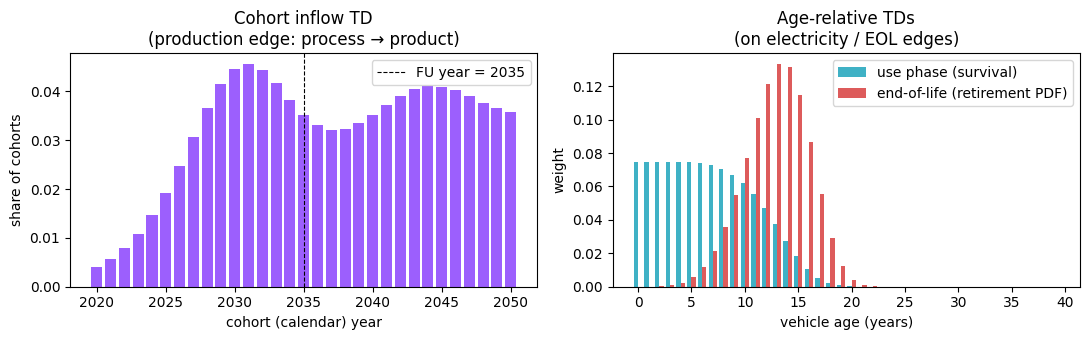

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(years_window, td_cohort_inflow.amount, color="#9c5ffd")
axes[0].axvline(FU_YEAR, color="k", ls="--", lw=0.8, label=f"FU year = {FU_YEAR}")
axes[0].set(xlabel="cohort (calendar) year", ylabel="share of cohorts",
            title="Cohort inflow TD\n(production edge: process \u2192 product)")
axes[0].legend()

use_age_int = td_use_age.date.astype("timedelta64[Y]").astype(int)
eol_age_int = td_eol_age.date.astype("timedelta64[Y]").astype(int)
axes[1].bar(use_age_int - 0.2, td_use_age.amount, width=0.4, color="#3fb1c5",
            label="use phase (survival)")
axes[1].bar(eol_age_int + 0.2, td_eol_age.amount, width=0.4, color="#dd5b5b",
            label="end-of-life (retirement PDF)")
axes[1].set(xlabel="vehicle age (years)", ylabel="weight",
            title="Age-relative TDs\n(on electricity / EOL edges)")
axes[1].legend()
fig.tight_layout()


## Vintage efficiency factors

We assume EVs get more efficient at the time of purchase: a vehicle built in 2020 uses
`ELECTRICITY_CONSUMPTION` kWh/km, but later cohorts use less. Numbers below are made up
(~0.7%/year improvement) — swap in whatever your scenario calls for.

**Why this requires the explicit product node.** Without a separate product node, the
process and product timestamps would coincide and the distinction between *when the vehicle
was built* and *when it is driving* would collapse — both would just be "the time of the
exchange". The explicit product splits these into two separate timestamps that ride together
through the graph: `date_consumer` (= cohort year, born on the production edge) and
`date_producer` (= calendar year of the actual exchange).

`temporal_evolution_factors` then has a clean two-mode interpretation depending on which
timestamp you key it to:

- `temporal_evolution_reference="consumer"` → factor evaluated at the **cohort year**. A 2020
  vehicle keeps its 2020 kWh/km even when driving in 2040 — vintage locking.
- `temporal_evolution_reference="producer"` → factor evaluated at the **calendar year of
  consumption**. All vehicles, regardless of vintage, see the latest factor whenever they are
  driving — system-wide retrofit / learning.

This notebook uses `"consumer"` to demonstrate vintage locking. Switching modes is a
one-keyword change.


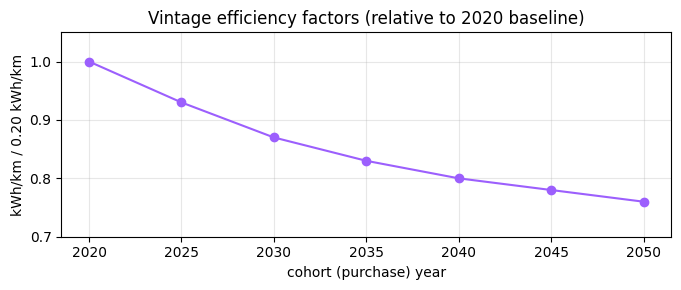

In [11]:
from datetime import datetime

vintage_efficiency_factors = {
    datetime(2020, 1, 1): 1.00,
    datetime(2025, 1, 1): 0.93,
    datetime(2030, 1, 1): 0.87,
    datetime(2035, 1, 1): 0.83,
    datetime(2040, 1, 1): 0.80,
    datetime(2045, 1, 1): 0.78,
    datetime(2050, 1, 1): 0.76,
}

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot([d.year for d in vintage_efficiency_factors],
        list(vintage_efficiency_factors.values()),
        marker="o", color="#9c5ffd")
ax.set(xlabel="cohort (purchase) year",
       ylabel=f"kWh/km / {ELECTRICITY_CONSUMPTION:.2f} kWh/km",
       title="Vintage efficiency factors (relative to 2020 baseline)",
       ylim=(0.7, 1.05))
ax.grid(alpha=0.3)
fig.tight_layout()


## Foreground system — explicit process and product

The whole foreground is **one product** (`ev_fleet_product`) and **one process**
(`ev_fleet_process`). Compare to the original example with four foreground nodes
(`fleet_service`, `fleet_driving`, `ev_production`, `used_ev`) — the explicit paradigm collapses
all of that into the dual structure below.

```{mermaid}
flowchart LR
    glider(glider production):::ei-->ev_fleet_process
    powertrain(powertrain production):::ei-->ev_fleet_process
    battery(battery production):::ei-->ev_fleet_process
    electricity(electricity generation):::ei-->|age survival TD<br/>+ vintage factors|ev_fleet_process
    ev_fleet_process(EV fleet process):::fg-->|cohort inflow TD<br/>production edge|ev_fleet_product([EV fleet product]):::fg
    ev_fleet_process-->|age retirement TD|glider_eol(glider eol):::ei
    ev_fleet_process-->|age retirement TD|powertrain_eol(powertrain eol):::ei
    ev_fleet_process-->|age retirement TD|battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

### What each node is, and why

**`ev_fleet_product`** is a *thing*: the abstract "vehicle-lifetime" unit of fleet service. It is
deliberately bare — `name`, `unit`, `type=bd.labels.product_node_default`, no exchanges, no
`reference product`. Its only job is to be the **demand handle**: the FU is
`{ev_fleet_product: n_total_inflow}`. Because it sits as its own technosphere row, we can attach
TDs to *its incoming and outgoing edges* without those TDs ever being conflated with the
process operation that produced it.

**`ev_fleet_process`** is the *operation*: the per-cohort-vehicle life-cycle. All technosphere
and biosphere edges live here:

- *Build* edges (glider, powertrain, battery): per-vehicle masses, no TD — the build is treated
  as a point event at the cohort year (age 0).
- *Use* edge (electricity): lifetime kWh per vehicle, with the **age survival TD** spreading
  consumption across the vehicle's lifetime, and `temporal_evolution_factors` (consumer-ref)
  scaling each cohort by its vintage efficiency.
- *EOL* edges (glider/powertrain/battery EOL): per-vehicle masses with the **age retirement
  PDF** TD — each cohort retires at a Weibull-distributed age.

Note what `ev_fleet_process` does *not* have: a `reference product` field, a self-production
edge, or any embedded product knowledge. The product is a separate node, reached only via the
production edge with the cohort TD on it.

### TDs on both "sides" of the product

This is the core of the modelling pattern. The product node has two sides:

- **Upstream (production) side** — the edge `ev_fleet_process → ev_fleet_product`. Its TD says
  *when production happens* relative to the demand. Here this is the **cohort TD**: a calendar-year
  distribution that places one production event per cohort year, weighted by inflow share.
- **Downstream (consumption) side** — edges from any consumer of the product, including the
  functional unit itself. Their TDs say *when the product is being consumed*. In this notebook
  the only consumer is the FU, which is anchored at `FU_YEAR` with no TD (a point mass at
  `FU_YEAR`). In a richer model — e.g. a downstream taxi service consuming `ev_fleet_product`
  with its own demand profile — that consumer's TD would also live on this side.

When `bw_timex` evaluates the system, it **convolves these two sides at the product node**.
The consumer TD shifts the demand profile through time; the production TD then says *for each
demand instant* when the producing process actually ran. The composite result is propagated
downward into every exchange of `ev_fleet_process` as a `(date_consumer, date_producer)` pair.
Concretely:

- `date_consumer` = cohort year (the moment the product instance was "made")
- `date_producer` = calendar year of the actual technosphere/biosphere event (cohort year +
  age, for use/EOL edges)

That double-indexing is what makes the rest of the model expressive. `bw_timex` automatically
relinks each exchange to the right time-stamped background database based on `date_producer`,
so vehicles built in 2025 source 2025-vintage materials and electricity. And
`temporal_evolution_factors` with `reference="consumer"` evaluates the foreground efficiency
factor at the *cohort year* — not the calendar year — so vintage locking falls out for free.

All amounts on the process edges are *per cohort vehicle*. The total fleet scaling enters via
the FU demand: `{ev_fleet_product: n_total_inflow}`.


### Step 1 — define the two foreground nodes

The product is bare metadata: just `name`, `unit`, and `type=bd.labels.product_node_default`.
We deliberately do *not* set a `reference product` field on it (it *is* the reference
product). The process gets `name`, `location`, and `type=bd.labels.process_node_default` — also
no `reference product`, since the production edge below points explicitly at the product.


In [12]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

ev_fleet_product = foreground.new_node(
    code="ev_fleet_product",
    name="EV fleet vehicle-lifetime",
    unit="vehicle-lifetime",
    type=bd.labels.product_node_default,
)
ev_fleet_product.save()

ev_fleet_process = foreground.new_node(
    code="ev_fleet_process",
    name="EV fleet operation (per cohort vehicle, life-cycle)",
    location="GLO",
    type=bd.labels.process_node_default,
)
ev_fleet_process.save()


### Step 2 — wire up the edges (all on the process)

All edges live on `ev_fleet_process`. The product never carries an exchange. We start with the
**production edge** that connects the two — this is where the cohort TD goes — and then add the
build / use / EOL technosphere edges, with their respective age-relative TDs.


In [13]:
# Pull background activities (we use the 2020 names; bw_timex relinks them across DBs at runtime).
glider_node      = background_2020.get(code="glider")
powertrain_node  = background_2020.get(code="powertrain")
battery_node     = background_2020.get(code="battery")
electricity_node = background_2020.get(code="electricity")
glider_eol       = background_2020.get(code="glider_eol")
powertrain_eol   = background_2020.get(code="powertrain_eol")
battery_eol      = background_2020.get(code="battery_eol")

# --- Upstream side of the product: production edge (process -> product). ---
# Amount = 1 vehicle-lifetime per cohort vehicle. The cohort TD splits this into one
# production event per cohort year, weighted by inflow share.
ev_fleet_process.new_edge(
    input=ev_fleet_product,
    amount=1,
    type=bd.labels.production_edge_default,
    temporal_distribution=td_cohort_inflow,
).save()

# --- Build phase: per-vehicle masses, point mass at age 0 (no TD = at the cohort year). ---
ev_fleet_process.new_edge(
    input=glider_node, amount=MASS_GLIDER, type=bd.labels.consumption_edge_default,
).save()
ev_fleet_process.new_edge(
    input=powertrain_node, amount=MASS_POWERTRAIN, type=bd.labels.consumption_edge_default,
).save()
ev_fleet_process.new_edge(
    input=battery_node, amount=MASS_BATTERY, type=bd.labels.consumption_edge_default,
).save()

# --- Use phase: lifetime kWh per vehicle, spread over ages by the survival TD. ---
# `temporal_evolution_reference="consumer"` makes the vintage factor evaluate at the cohort
# (consumer) year, not the calendar (producer) year — i.e. true vintage locking.
electricity_edge = ev_fleet_process.new_edge(
    input=electricity_node,
    amount=ANNUAL_MILEAGE * ELECTRICITY_CONSUMPTION * mean_lifetime_years,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=td_use_age,
)
electricity_edge["temporal_evolution_factors"]   = vintage_efficiency_factors
electricity_edge["temporal_evolution_reference"] = "consumer"
electricity_edge.save()

# --- End-of-life: one retirement event per vehicle, distributed over ages by the PDF TD. ---
ev_fleet_process.new_edge(
    input=glider_eol, amount=-MASS_GLIDER,
    type=bd.labels.consumption_edge_default, temporal_distribution=td_eol_age,
).save()
ev_fleet_process.new_edge(
    input=powertrain_eol, amount=-MASS_POWERTRAIN,
    type=bd.labels.consumption_edge_default, temporal_distribution=td_eol_age,
).save()
ev_fleet_process.new_edge(
    input=battery_eol, amount=-MASS_BATTERY,
    type=bd.labels.consumption_edge_default, temporal_distribution=td_eol_age,
).save()

for db in bd.databases:
    bd.Database(db).process()


## Characterization method


In [14]:
bd.Method(("GWP", "example")).write([(("biosphere", "CO2"), 1)])
method = ("GWP", "example")


## Time-explicit fleet LCA

We anchor the timeline at `FU_YEAR` (2035) by passing it as `starting_datetime` to
`build_timeline`. All offsets in our TDs are interpreted relative to that anchor. The functional
unit is `n_total_inflow` units of `ev_fleet_product` — i.e. the entire fleet over the analysis
horizon.


In [15]:
from bw_timex import TimexLCA

database_dates = {
    "background_2020": datetime.strptime("2020", "%Y"),
    "background_2030": datetime.strptime("2030", "%Y"),
    "background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

tlca = TimexLCA(
    demand={ev_fleet_product: n_total_inflow},
    method=method,
    database_dates=database_dates,
)
tlca.build_timeline(
    starting_datetime=datetime(FU_YEAR, 1, 1),
    temporal_grouping="year",
)


2026-05-04 08:52:19.450 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...
2026-05-04 08:52:19.451 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...
2026-05-04 08:52:19.461 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...
2026-05-04 08:52:19.466 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.
2026-05-04 08:52:19.468 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...
2026-05-04 08:52:19.469 | INFO     | bw_timex.timeline_builder:__init__:100 - Traversing supply chain graph...
2026-05-04 08:52:19.481 | INFO     | bw_timex.timeline_builder:build_timeline:156 - Building timeline...
2026-05-04 08:52:19.551 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2041-01-01 00:00:00 is higher than all provided dates. Data will be taken from the close

Starting graph traversal
Calculation count: 7


2026-05-04 08:52:19.670 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2072-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:19.670 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2072-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:19.670 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2072-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:19.671 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2073-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:19.671 | INFO     | bw_time

,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2035-01-01,glider,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",840.0,"{'background_2030': 0.5, 'background_2040': 0.5}"
1,2035-01-01,powertrain,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",80.0,"{'background_2030': 0.5, 'background_2040': 0.5}"
2,2035-01-01,battery,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",280.0,"{'background_2030': 0.5, 'background_2040': 0.5}"
3,2035-01-01,electricity,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",2400.00007,"{'background_2030': 0.5, 'background_2040': 0.5}"
4,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",2035-01-01,-1,1.0,None
...,...,...,...,...,...,...
156,2073-01-01,battery_eol,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",-0.0,{'background_2040': 1}
157,2074-01-01,electricity,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",0.0,{'background_2040': 1}
158,2074-01-01,glider_eol,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",-0.0,{'background_2040': 1}
159,2074-01-01,powertrain_eol,2035-01-01,"EV fleet operation (per cohort vehicle, life-c...",-0.0,{'background_2040': 1}


In [16]:
tlca.lci()
tlca.static_lcia()
print(f"Time-explicit fleet GWP: {tlca.static_score:>14,.0f} kg CO2-eq")
print(f"Static (2020 background) fleet GWP: {tlca.base_lca.score:>14,.0f} kg CO2-eq")
print(f"\nPer-vehicle GWP, time-explicit: {tlca.static_score / n_total_inflow:>10,.0f} kg CO2-eq / vehicle")
print(f"Per-vehicle GWP, static (2020): {tlca.base_lca.score / n_total_inflow:>10,.0f} kg CO2-eq / vehicle")


2026-05-04 08:52:19.704 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...
2026-05-04 08:52:19.847 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Time-explicit fleet GWP: 31,477,120,065 kg CO2-eq
Static (2020 background) fleet GWP: 120,320,351,786 kg CO2-eq

Per-vehicle GWP, time-explicit:      7,617 kg CO2-eq / vehicle
Per-vehicle GWP, static (2020):     29,114 kg CO2-eq / vehicle


### Dynamic characterization


Cumulative fleet radiative forcing: 2.747e-03 W/m²


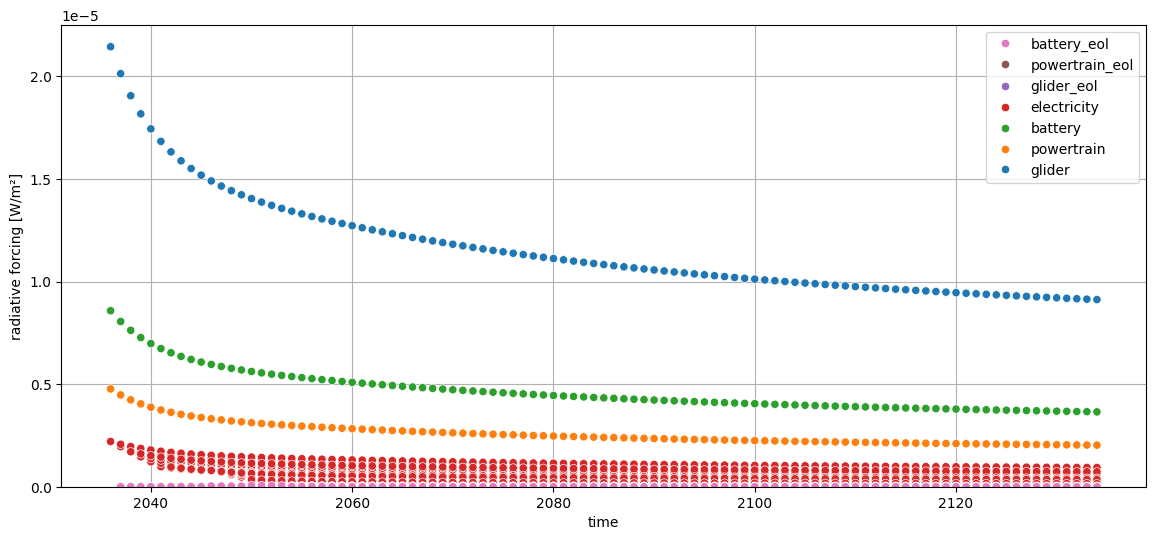

In [17]:
from dynamic_characterization.ipcc_ar6.radiative_forcing import characterize_co2

characterization_functions = {bd.get_node(code="CO2").id: characterize_co2}

tlca.dynamic_lcia(
    metric="radiative_forcing",
    fixed_time_horizon=True,
    characterization_functions=characterization_functions,
)
print(f"Cumulative fleet radiative forcing: {tlca.dynamic_score:.3e} W/m\u00b2")
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)


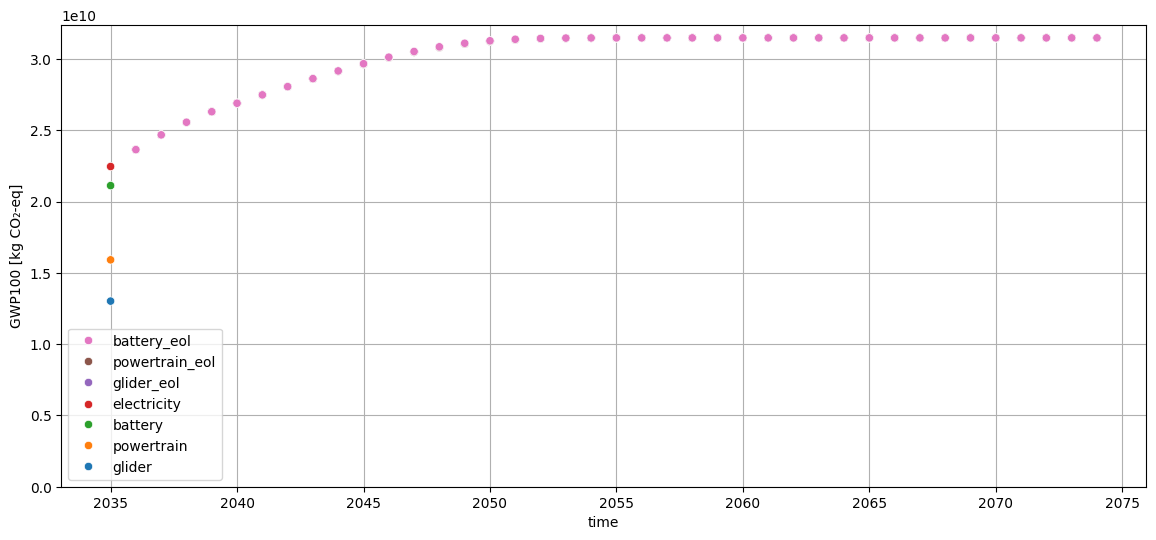

In [18]:
tlca.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)


## Validating the cohort × vintage tracking

We can check that `bw_timex` is doing what we expect by comparing its prediction to a hand-rolled
calculation that uses *only* flodym outputs and the vintage factors. For a fixed calendar year
`y`, the electricity consumption attributable to the cohort produced in year `c` is

$$E_{c,y} \;=\; \text{stock\_by\_cohort}[y, c] \;\times\; \text{ANNUAL\_MILEAGE} \;\times\;
\text{ELECTRICITY\_CONSUMPTION} \;\times\; f_{\text{vintage}}(c).$$

Summed over `c`, this gives the year-`y` fleet electricity demand. The plot below shows that
decomposition for `TARGET_YEAR = 2030`: the bars are the per-cohort kWh, and their colour encodes
the vintage efficiency factor. Older cohorts contribute disproportionally more electricity (and
emissions) per vehicle — exactly the vintage-locking behaviour `temporal_evolution_factors` with
`reference="consumer"` encodes inside `bw_timex`.


Total fleet electricity in 2030: 2,178.6 GWh
  of which from cohorts ≤ 2025: 606.4 GWh
  of which from cohorts >  2025: 1,572.2 GWh


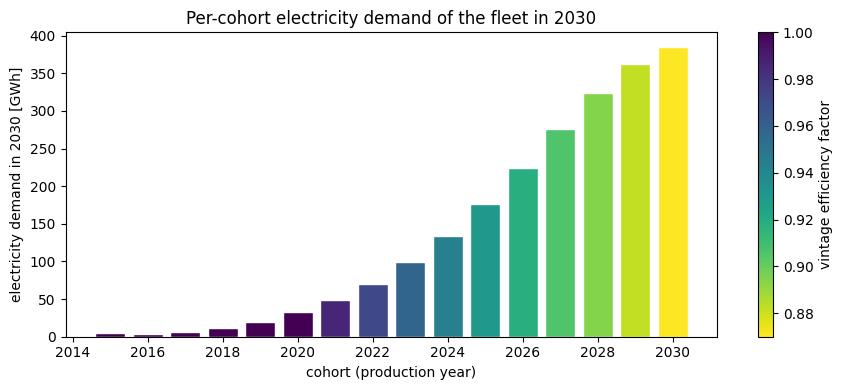

In [19]:
import matplotlib as mpl
from matplotlib.colors import Normalize

def vintage_factor_lookup(cohort_year: int) -> float:
    keys = sorted(vintage_efficiency_factors)
    yrs  = np.array([k.year for k in keys])
    vals = np.array([vintage_efficiency_factors[k] for k in keys])
    return float(np.interp(cohort_year, yrs, vals, left=vals[0], right=vals[-1]))

cohort_years_active = years[: yr_idx + 1]
vehicles_per_cohort = stock_by_cohort[yr_idx, : yr_idx + 1]
vintage_factors_active = np.array([vintage_factor_lookup(c) for c in cohort_years_active])

kwh_per_cohort = (
    vehicles_per_cohort
    * ANNUAL_MILEAGE
    * ELECTRICITY_CONSUMPTION
    * vintage_factors_active
)

norm = Normalize(vmin=vintage_factors_active.min(), vmax=vintage_factors_active.max())
cmap = mpl.cm.viridis_r
colors = cmap(norm(vintage_factors_active))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cohort_years_active, kwh_per_cohort / 1e6, color=colors, edgecolor="white")
ax.set(xlabel="cohort (production year)",
       ylabel=f"electricity demand in {TARGET_YEAR} [GWh]",
       title=f"Per-cohort electricity demand of the fleet in {TARGET_YEAR}")
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, label="vintage efficiency factor")
fig.tight_layout()

print(f"Total fleet electricity in {TARGET_YEAR}: {kwh_per_cohort.sum()/1e6:,.1f} GWh")
print(f"  of which from cohorts \u2264 2025: {kwh_per_cohort[cohort_years_active <= 2025].sum()/1e6:,.1f} GWh")
print(f"  of which from cohorts >  2025: {kwh_per_cohort[cohort_years_active >  2025].sum()/1e6:,.1f} GWh")


### Isolating the vintage-locking effect

To make the contribution of vintage locking visible, we rerun the same model with the
`temporal_evolution_factors` removed from the electricity edge and compare the dynamic GWP100
score to the run that included them. Everything else (cohort distribution, age-relative TDs,
background interpolation) is identical, so the difference is attributable purely to the foreground
vintage modifier.


In [20]:
saved_factors   = electricity_edge["temporal_evolution_factors"]
saved_reference = electricity_edge["temporal_evolution_reference"]
del electricity_edge["temporal_evolution_factors"]
del electricity_edge["temporal_evolution_reference"]
electricity_edge.save()
bd.Database("foreground").process()

tlca_no_evo = TimexLCA(
    demand={ev_fleet_product: n_total_inflow},
    method=method,
    database_dates=database_dates,
)
tlca_no_evo.build_timeline(
    starting_datetime=datetime(FU_YEAR, 1, 1),
    temporal_grouping="year",
)
tlca_no_evo.lci()
tlca_no_evo.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)

# Restore so any downstream rerun stays consistent.
electricity_edge["temporal_evolution_factors"]   = saved_factors
electricity_edge["temporal_evolution_reference"] = saved_reference
electricity_edge.save()
bd.Database("foreground").process()

score_no_evo   = tlca_no_evo.dynamic_score
score_with_evo = tlca.dynamic_score
delta = score_no_evo - score_with_evo
print(f"Time-explicit, NO foreground evo   : {score_no_evo:>16,.0f} kg CO2-eq")
print(f"Time-explicit, WITH vintage factors: {score_with_evo:>16,.0f} kg CO2-eq")
print(f"Vintage-learning savings           : {delta:>+16,.0f} kg CO2-eq "
      f"({delta / score_no_evo * 100:+.1f}%)")


2026-05-04 08:52:20.571 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...
2026-05-04 08:52:20.571 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...
2026-05-04 08:52:20.581 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...
2026-05-04 08:52:20.584 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.
2026-05-04 08:52:20.586 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...
2026-05-04 08:52:20.586 | INFO     | bw_timex.timeline_builder:__init__:100 - Traversing supply chain graph...
2026-05-04 08:52:20.597 | INFO     | bw_timex.timeline_builder:build_timeline:156 - Building timeline...
2026-05-04 08:52:20.610 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2041-01-01 00:00:00 is higher than all provided dates. Data will be taken from the close

Starting graph traversal
Calculation count: 7


2026-05-04 08:52:20.722 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2065-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:20.724 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2066-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:20.724 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2066-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:20.725 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:562 - Reference date 2066-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.
2026-05-04 08:52:20.726 | INFO     | bw_time

Time-explicit, NO foreground evo   :   33,963,485,474 kg CO2-eq
Time-explicit, WITH vintage factors:   31,477,120,065 kg CO2-eq
Vintage-learning savings           :   +2,486,365,409 kg CO2-eq (+7.3%)


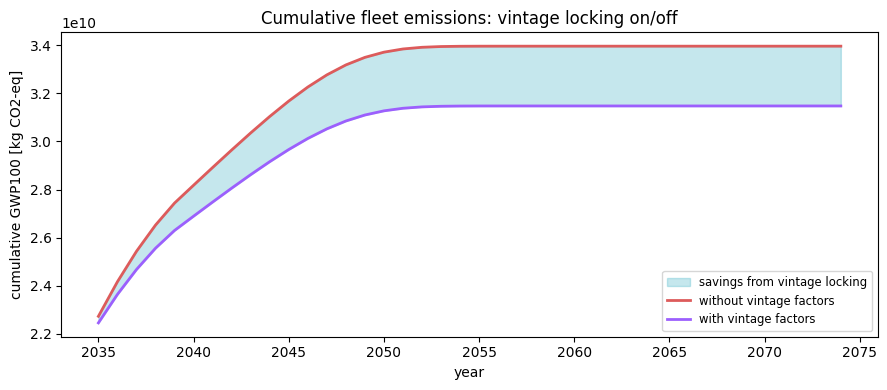

In [21]:
def yearly_total(tl):
    df = tl.characterized_inventory.copy()
    df["year"] = df["date"].dt.year
    return df.groupby("year")["amount"].sum()

yr_with    = yearly_total(tlca)
yr_without = yearly_total(tlca_no_evo)
years_idx  = sorted(set(yr_with.index) | set(yr_without.index))
yr_with    = yr_with.reindex(years_idx, fill_value=0)
yr_without = yr_without.reindex(years_idx, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(years_idx, yr_without.cumsum(), yr_with.cumsum(),
                color="#3fb1c5", alpha=0.3, label="savings from vintage locking")
ax.plot(years_idx, yr_without.cumsum(), color="#dd5b5b", lw=2, label="without vintage factors")
ax.plot(years_idx, yr_with.cumsum(),    color="#9c5ffd", lw=2, label="with vintage factors")
ax.set(xlabel="year", ylabel="cumulative GWP100 [kg CO2-eq]",
       title="Cumulative fleet emissions: vintage locking on/off")
ax.legend(loc="lower right", fontsize="small")
fig.tight_layout()


## Wrap-up

By moving to the explicit process/product paradigm, the fleet model collapses from four foreground
nodes (`fleet_service`, `fleet_driving`, `ev_production`, `used_ev`) to two: a single process and a
single product. The cohort timing rides on the production edge between them, and `bw_timex` does
the rest:

- automatic relinking of background inputs to the time-stamped databases (`background_2020/30/40`)
  at every cohort × age coordinate;
- temporal explosion via convolution of the cohort TD with the age TDs, so a single edge specification
  spawns the full cohort × calendar-year × age grid behind the scenes;
- per-cohort `temporal_evolution_factors` with `reference="consumer"`, which give us
  vintage-locked efficiencies — vehicles produced in 2020 keep their 2020 kWh/km even when they are
  still driving in 2030 alongside more efficient 2025 cohort members.

The flodym layer is doing the dMFA bookkeeping (stock-driven inflow, stock-by-cohort, age survival
and retirement profiles) and feeds the resulting time series into `bw_timex` as relative
TDs. From here, you can plug in any other lifetime distribution (`NormalLifetime`,
`LogNormalLifetime`, …), any other stock trajectory, or richer cohort effects (e.g. cohort-specific
battery chemistry by adding additional vintage factors on dedicated edges).
